# AM01 — Deep Interpretation of the Official Results

**Detection of anomalous behaviour in an industrial Kuka robot**  
This notebook condenses the main interpretative insights obtained from the official experiments.

It **does not retrain any model**. It reads the validated artifacts stored in:

```text
MyDrive/AM01/results/official
```

and produces reproducible visual evidence for the following questions:

1. Why does Smooth L1 improve the autoencoder much more than architectural complexity?
2. Does the AAE discover anomalies that the plain AE misses?
3. Which actions are intrinsically easy or difficult?
4. Which physical feature families carry the anomaly signal?
5. Why can accelerometers be anti-informative for a slowdown anomaly?
6. Does adversarial regularization actually shape the latent space, and does that help detection?
7. How do window length and segment selection affect the interpretation of the results?

> The notebook uses only validation-calibrated thresholds for operational comparisons. Any test-optimal threshold, when computed, is explicitly marked as **diagnostic only**.

## 0. Configuration

The environment variable `AM01_OFFICIAL_ROOT` can override the default Drive path. This makes the notebook executable both in Colab and in a local test environment.

In [1]:
from pathlib import Path
import os

DEFAULT_ROOT = Path('/content/drive/MyDrive/AM01/results/official')
OFFICIAL_ROOT = Path(os.environ.get('AM01_OFFICIAL_ROOT', str(DEFAULT_ROOT)))
TABLES_DIR = OFFICIAL_ROOT / 'tables'
RUNS_DIR = OFFICIAL_ROOT / 'runs'
WARMUP_DIR = OFFICIAL_ROOT / 'warmup_aae_smoothl1'

SAVE_FIGURES = True
FIGURE_DIR = OFFICIAL_ROOT / 'figures' / 'interpretation_notebook'
TABLE_OUTPUT_DIR = OFFICIAL_ROOT / 'tables' / 'interpretation_notebook'

print('Official results root:', OFFICIAL_ROOT)

Official results root: /content/drive/MyDrive/AM01/results/official


## 1. Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab: Google Drive mount skipped.')

if not OFFICIAL_ROOT.exists():
    raise FileNotFoundError(
        f'Official results folder not found: {OFFICIAL_ROOT}\n'
        'Mount Drive or set AM01_OFFICIAL_ROOT to the correct local path.'
    )

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 2. Imports and plotting utilities

In [3]:
import json
import math
import warnings
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    f1_score,
)

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})


def finish_figure(name: str, *, tight: bool = True):
    if tight:
        plt.tight_layout()
    if SAVE_FIGURES:
        path = FIGURE_DIR / f'{name}.png'
        plt.savefig(path, bbox_inches='tight')
        print('Saved:', path)
    plt.show()


def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f'Required artifact missing: {path}')
    return path


def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(require_file(path))


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None


def read_json(path: Path) -> dict:
    with open(require_file(path), 'r', encoding='utf-8') as f:
        return json.load(f)

## 3. Artifact audit and official tables

The cell below verifies the minimum set of tables needed for the analysis. The model score files are loaded separately from their official run folders.

In [4]:
TABLE_FILES = OrderedDict({
    'main_results': TABLES_DIR / 'main_results_full.csv',
    'loss_ablation': TABLES_DIR / 'preprocessing_loss_ablation.csv',
    'per_feature': TABLES_DIR / 'per_feature_reconstruction.csv',
    'per_action': TABLES_DIR / 'per_action_metrics.csv',
    'window_sensitivity': TABLES_DIR / 'window_length_sensitivity.csv',
    'segment_lengths': TABLES_DIR / 'segment_lengths.csv',
    'aae_scores': TABLES_DIR / 'aae_specific_scores.csv',
    'aae_latent_pca': TABLES_DIR / 'aae_latent_pca_coordinates.csv',
    'aae_ablation': TABLES_DIR / 'aae_ablation_results.csv',
})

status = pd.DataFrame({
    'artifact': TABLE_FILES.keys(),
    'path': [str(p) for p in TABLE_FILES.values()],
    'exists': [p.exists() for p in TABLE_FILES.values()],
})
display(status)

missing = status.loc[~status['exists'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing required tables:\n' + '\n'.join(missing))

main_results = read_csv(TABLE_FILES['main_results'])
loss_ablation = read_csv(TABLE_FILES['loss_ablation'])
per_feature = read_csv(TABLE_FILES['per_feature'])
per_action = read_csv(TABLE_FILES['per_action'])
window_sensitivity = read_csv(TABLE_FILES['window_sensitivity'])
segment_lengths = read_csv(TABLE_FILES['segment_lengths'])
aae_scores = read_csv(TABLE_FILES['aae_scores'])
aae_latent = read_csv(TABLE_FILES['aae_latent_pca'])
aae_ablation = read_csv(TABLE_FILES['aae_ablation'])

multiseed_summary = read_optional_csv(
    WARMUP_DIR / 'tables' / 'confirmation_multiseed_summary.csv'
)
warmup_grid = read_optional_csv(WARMUP_DIR / 'tables' / 'warmup_grid_results.csv')
warmup_history = read_optional_csv(WARMUP_DIR / 'tables' / 'best_warmup_history.csv')

print('Loaded official tables successfully.')

,artifact,path,exists
0,main_results,/content/drive/MyDrive/AM01/results/official/t...,True
1,loss_ablation,/content/drive/MyDrive/AM01/results/official/t...,True
2,per_feature,/content/drive/MyDrive/AM01/results/official/t...,True
3,per_action,/content/drive/MyDrive/AM01/results/official/t...,True
4,window_sensitivity,/content/drive/MyDrive/AM01/results/official/t...,True
5,segment_lengths,/content/drive/MyDrive/AM01/results/official/t...,True
6,aae_scores,/content/drive/MyDrive/AM01/results/official/t...,True
7,aae_latent_pca,/content/drive/MyDrive/AM01/results/official/t...,True
8,aae_ablation,/content/drive/MyDrive/AM01/results/official/t...,True


Loaded official tables successfully.


## 4. Load aligned window scores and thresholds

All window-level comparisons use the exact key `(run_id, start)`. The threshold is read from the corresponding `metrics.json`, so scores and cut-offs cannot be accidentally mixed across experiments.

In [5]:
RUN_SPECS = OrderedDict({
    'PCA': RUNS_DIR / 'main' / 'pca_seed42',
    'Isolation Forest': RUNS_DIR / 'main' / 'isolation_forest_seed42',
    'AE MLP — MSE': RUNS_DIR / 'main' / 'ae_mlp_seed42',
    'ConvAE — MSE': RUNS_DIR / 'main' / 'ae_conv1d_seed42',
    'AAE MLP — MSE': RUNS_DIR / 'main' / 'aae_mlp_seed42',
    'AE MLP — Smooth L1': RUNS_DIR / 'preprocessing_loss' / 'ae_mlp_seed42_scalerstandard_losshuber',
    'AAE MLP — Smooth L1': RUNS_DIR / 'preprocessing_loss' / 'aae_mlp_seed42_scalerstandard_losshuber',
})


def load_run_artifacts(name: str, run_dir: Path) -> dict:
    metrics = read_json(run_dir / 'metrics.json')
    test = read_csv(run_dir / 'scores_test.csv')
    val = read_csv(run_dir / 'scores_val.csv')
    threshold = float(metrics['threshold'])

    for frame in (test, val):
        required = {'run_id', 'start', 'score', 'label'}
        if not required.issubset(frame.columns):
            raise ValueError(f'{name}: malformed score file; missing {required - set(frame.columns)}')
        frame['prediction'] = (frame['score'] >= threshold).astype(int)

    val_normal_std = float(val.loc[val['label'] == 0, 'score'].std(ddof=0))
    if not np.isfinite(val_normal_std) or val_normal_std == 0:
        val_normal_std = 1.0

    return {
        'name': name,
        'run_dir': run_dir,
        'threshold': threshold,
        'metrics': metrics,
        'test': test,
        'val': val,
        'val_normal_std': val_normal_std,
    }


runs = {name: load_run_artifacts(name, path) for name, path in RUN_SPECS.items()}

alignment_keys = [
    set(zip(obj['test']['run_id'], obj['test']['start']))
    for obj in runs.values()
]
assert all(keys == alignment_keys[0] for keys in alignment_keys[1:]), \
    'The official score files are not aligned on (run_id, start).'

summary_rows = []
for name, obj in runs.items():
    df = obj['test']
    y, pred = df['label'].to_numpy(), df['prediction'].to_numpy()
    tp = int(((y == 1) & (pred == 1)).sum())
    fn = int(((y == 1) & (pred == 0)).sum())
    fp = int(((y == 0) & (pred == 1)).sum())
    tn = int(((y == 0) & (pred == 0)).sum())
    summary_rows.append({
        'model': name,
        'threshold': obj['threshold'],
        'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
        'precision': tp / max(tp + fp, 1),
        'recall': tp / max(tp + fn, 1),
        'f1': f1_score(y, pred),
        'pr_auc': average_precision_score(y, df['score']),
        'roc_auc': roc_auc_score(y, df['score']),
    })

window_summary = pd.DataFrame(summary_rows)
display(window_summary.round(4))
window_summary.to_csv(TABLE_OUTPUT_DIR / 'window_level_recomputed_summary.csv', index=False)

,model,threshold,tp,fn,fp,tn,precision,recall,f1,pr_auc,roc_auc
0,PCA,0.0750,179,141,411,833,0.3034,0.5594,0.3934,0.2873,0.6883
1,Isolation Forest,-0.0391,273,47,170,1074,0.6163,0.8531,0.7156,0.7196,0.9370
2,AE MLP — MSE,0.2974,281,39,319,925,0.4683,0.8781,0.6109,0.4570,0.8481
3,ConvAE — MSE,0.4859,225,95,192,1052,0.5396,0.7031,0.6106,0.4572,0.8281
4,AAE MLP — MSE,0.3306,271,49,344,900,0.4407,0.8469,0.5797,0.4437,0.8266
5,AE MLP — Smooth L1,0.1240,275,45,133,1111,0.6740,0.8594,0.7555,0.7634,0.9418
6,AAE MLP — Smooth L1,0.1501,253,67,160,1084,0.6126,0.7906,0.6903,0.7080,0.9035


# Part I — Global evidence

## 5. Main model comparison

The first visualization separates **ranking quality** (PR-AUC) from threshold-dependent performance. PR-AUC is especially important because it evaluates the ordering of anomalous and normal windows across all thresholds.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/01_pr_auc_model_comparison.png


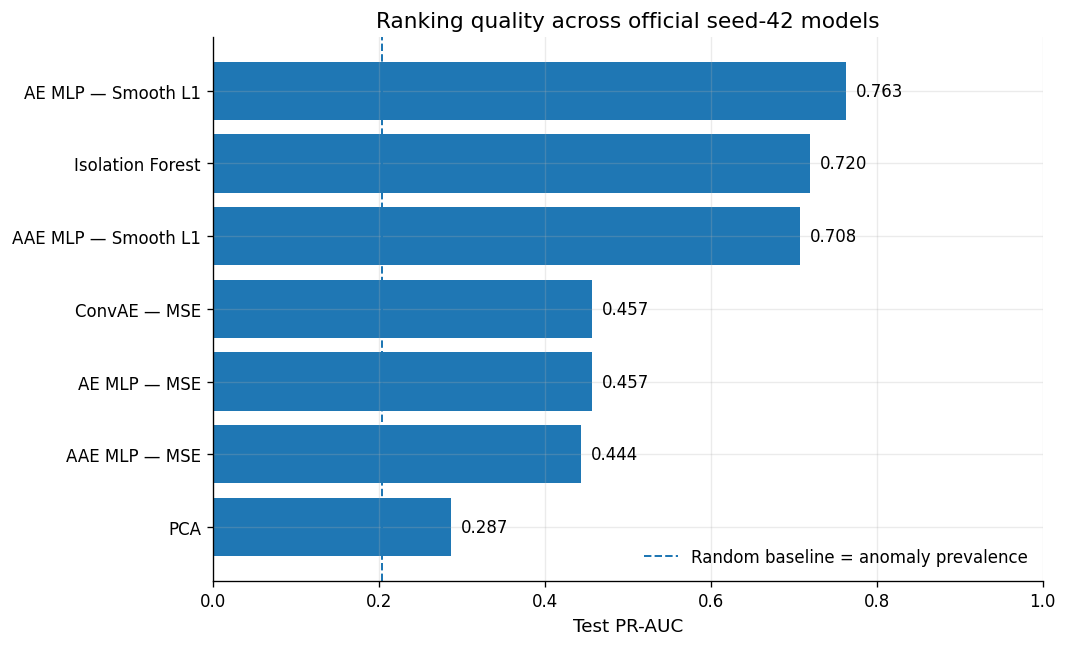

In [6]:
plot_df = window_summary.sort_values('pr_auc', ascending=True)

plt.figure(figsize=(9, 5.5))
plt.barh(plot_df['model'], plot_df['pr_auc'])
plt.axvline(plot_df['label_prevalence'].iloc[0] if 'label_prevalence' in plot_df else 320/1564,
            linestyle='--', linewidth=1.2, label='Random baseline = anomaly prevalence')
plt.xlabel('Test PR-AUC')
plt.title('Ranking quality across official seed-42 models')
plt.xlim(0, 1)
plt.legend(loc='lower right')
for i, value in enumerate(plot_df['pr_auc']):
    plt.text(value + 0.012, i, f'{value:.3f}', va='center')
finish_figure('01_pr_auc_model_comparison')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/02_f1_model_comparison.png


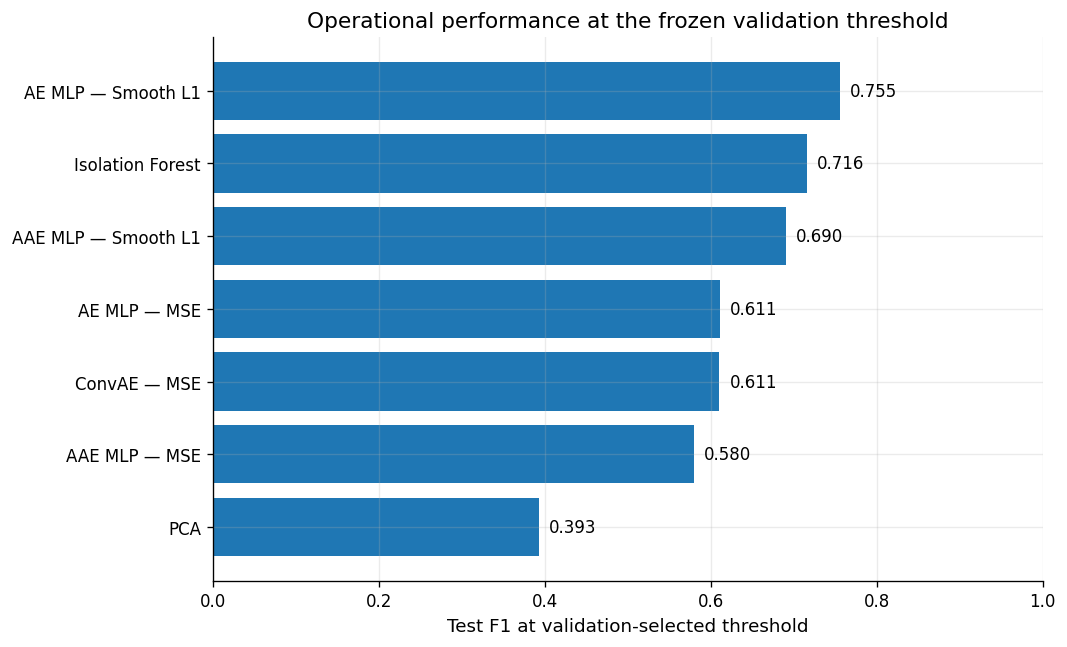

In [7]:
plot_df = window_summary.sort_values('f1', ascending=True)

plt.figure(figsize=(9, 5.5))
plt.barh(plot_df['model'], plot_df['f1'])
plt.xlabel('Test F1 at validation-selected threshold')
plt.title('Operational performance at the frozen validation threshold')
plt.xlim(0, 1)
for i, value in enumerate(plot_df['f1']):
    plt.text(value + 0.012, i, f'{value:.3f}', va='center')
finish_figure('02_f1_model_comparison')

### Interpretation

- Isolation Forest is the strongest MSE-protocol detector because the slowdown is well exposed by window statistics.
- The plain MLP AE and ConvAE have nearly identical PR-AUC under MSE, despite very different architectures.
- Changing the reconstruction loss to Smooth L1 produces a larger gain than changing the architecture or imposing an adversarial prior.
- The AAE remains below the corresponding plain AE under both MSE and Smooth L1.

## 6. Multi-seed confirmation

Seed changes affect both model optimization and the run split. Therefore, the variability below reflects the robustness of the complete experimental pipeline, not initialization alone.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/03_multiseed_pr_auc.png


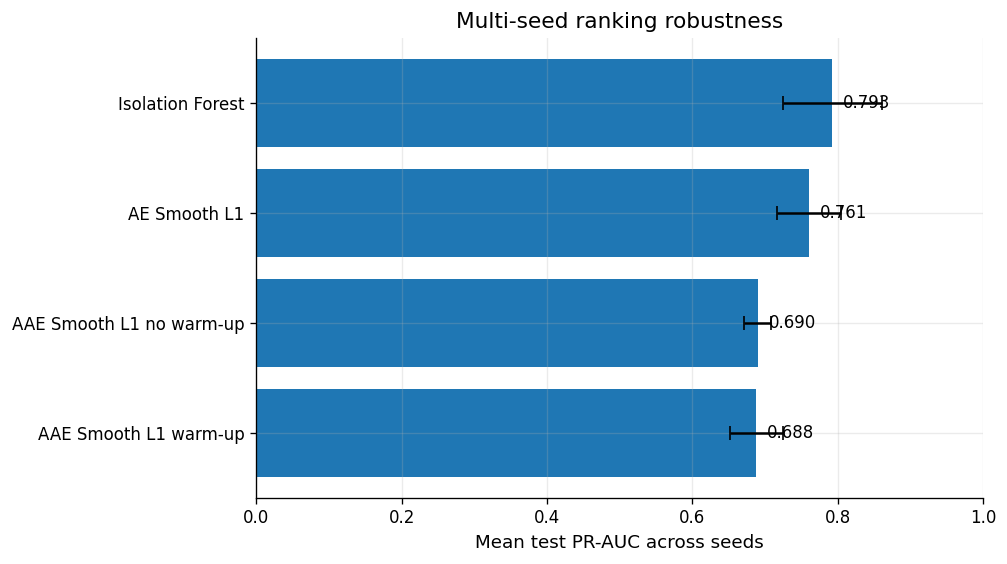

,experiment,mean_test_pr_auc,std_test_pr_auc,mean_test_f1,std_test_f1,mean_false_alarms_per_run
3,AAE Smooth L1 warm-up,0.6884,0.0370,0.6692,0.0054,0.1771
2,AAE Smooth L1 no warm-up,0.6902,0.0185,0.6696,0.0388,0.1714
1,AE Smooth L1,0.7608,0.0442,0.7455,0.0164,0.1081
0,Isolation Forest,0.7929,0.0677,0.7511,0.0298,0.1246


In [8]:
if multiseed_summary is None:
    print('Multi-seed summary not found; section skipped.')
else:
    ms = multiseed_summary.sort_values('mean_test_pr_auc', ascending=True)
    plt.figure(figsize=(8.5, 4.8))
    plt.barh(ms['experiment'], ms['mean_test_pr_auc'], xerr=ms['std_test_pr_auc'], capsize=4)
    plt.xlabel('Mean test PR-AUC across seeds')
    plt.title('Multi-seed ranking robustness')
    plt.xlim(0, 1)
    for i, value in enumerate(ms['mean_test_pr_auc']):
        plt.text(value + 0.015, i, f'{value:.3f}', va='center')
    finish_figure('03_multiseed_pr_auc')
    display(ms.round(4))

# Part II — Why Smooth L1 changes the result

## 7. Score distributions: MSE versus Smooth L1

The plots use the empirical score distributions of the same official test windows. The vertical line is the threshold selected on validation.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/04_ae_mse_score_distribution.png


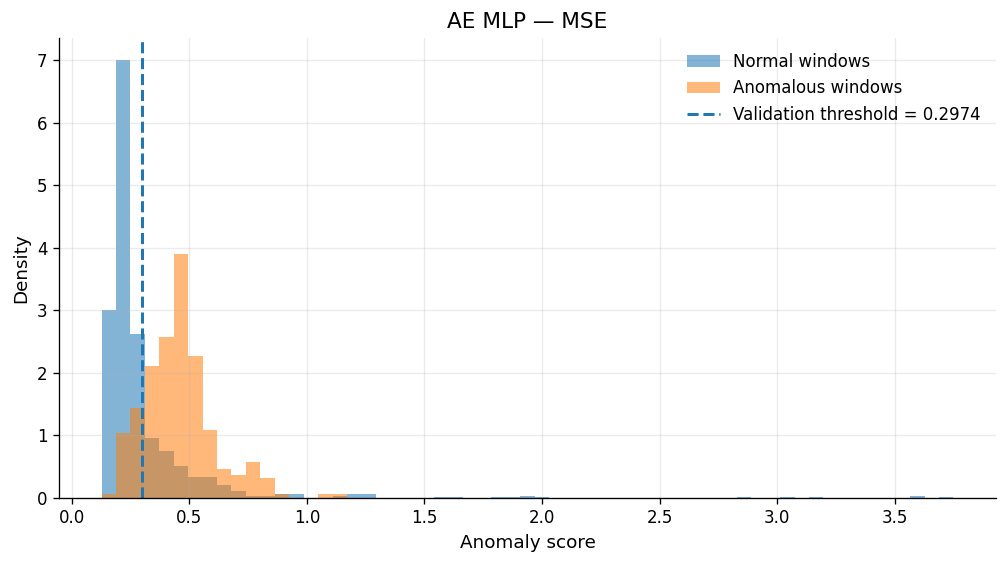

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/05_ae_smoothl1_score_distribution.png


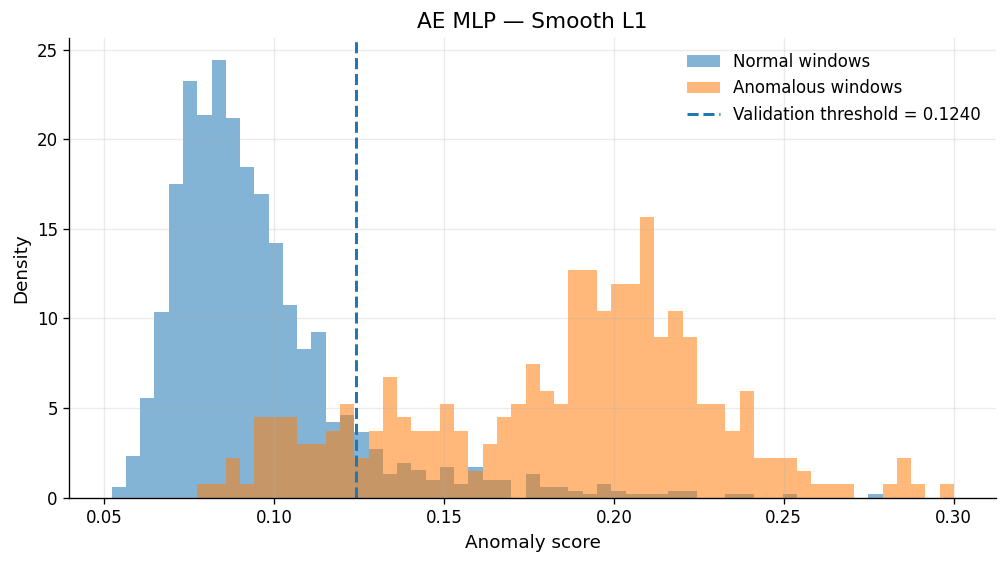

In [9]:
def plot_score_distribution(model_name: str, figure_name: str):
    obj = runs[model_name]
    df = obj['test']
    upper = float(df['score'].quantile(0.995))
    bins = np.linspace(float(df['score'].min()), upper, 60)

    plt.figure(figsize=(8.5, 4.8))
    plt.hist(df.loc[df['label'] == 0, 'score'], bins=bins, density=True,
             alpha=0.55, label='Normal windows')
    plt.hist(df.loc[df['label'] == 1, 'score'], bins=bins, density=True,
             alpha=0.55, label='Anomalous windows')
    plt.axvline(obj['threshold'], linestyle='--', linewidth=1.8,
                label=f'Validation threshold = {obj["threshold"]:.4f}')
    plt.xlabel('Anomaly score')
    plt.ylabel('Density')
    plt.title(model_name)
    plt.legend()
    finish_figure(figure_name)

plot_score_distribution('AE MLP — MSE', '04_ae_mse_score_distribution')
plot_score_distribution('AE MLP — Smooth L1', '05_ae_smoothl1_score_distribution')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/06_ae_mse_vs_smoothl1_counts.png


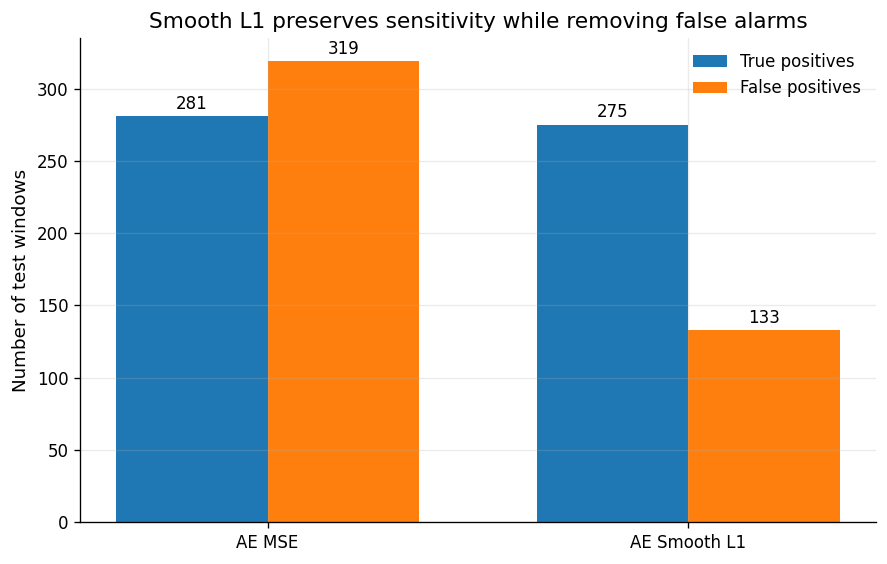

**Observed effect:** false positives decrease by **58.3%**, while true positives change by only **-6 windows**.

In [10]:
compare = window_summary.set_index('model').loc[
    ['AE MLP — MSE', 'AE MLP — Smooth L1'],
    ['tp', 'fp', 'fn', 'tn']
].copy()

counts = pd.DataFrame({
    'True positives': compare['tp'],
    'False positives': compare['fp'],
})

x = np.arange(len(counts.index))
width = 0.36
plt.figure(figsize=(7.5, 4.8))
plt.bar(x - width/2, counts['True positives'], width, label='True positives')
plt.bar(x + width/2, counts['False positives'], width, label='False positives')
plt.xticks(x, ['AE MSE', 'AE Smooth L1'])
plt.ylabel('Number of test windows')
plt.title('Smooth L1 preserves sensitivity while removing false alarms')
plt.legend()
for i, row in enumerate(counts.itertuples(index=False)):
    plt.text(i - width/2, row[0] + 5, str(int(row[0])), ha='center')
    plt.text(i + width/2, row[1] + 5, str(int(row[1])), ha='center')
finish_figure('06_ae_mse_vs_smoothl1_counts')

fp_reduction = 1 - compare.loc['AE MLP — Smooth L1', 'fp'] / compare.loc['AE MLP — MSE', 'fp']
tp_change = compare.loc['AE MLP — Smooth L1', 'tp'] - compare.loc['AE MLP — MSE', 'tp']
display(Markdown(
    f'**Observed effect:** false positives decrease by **{fp_reduction:.1%}**, '
    f'while true positives change by only **{tp_change:+.0f} windows**.'
))

### Interpretation

MSE allows a few very large residuals from difficult but legitimate normal windows to dominate the score. Smooth L1 compresses these extreme residuals. The important effect is not a large increase in anomaly recall; it is a much cleaner normal-score distribution and therefore a large reduction in false alarms.

# Part III — Does the AAE add genuinely new detections?

## 8. Window-level AE–AAE agreement

The next two plots distinguish predictions shared by the models from detections unique to one model. The comparison uses the strongest neural protocol: StandardScaler + Smooth L1.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/07_ae_aae_anomaly_window_agreement.png


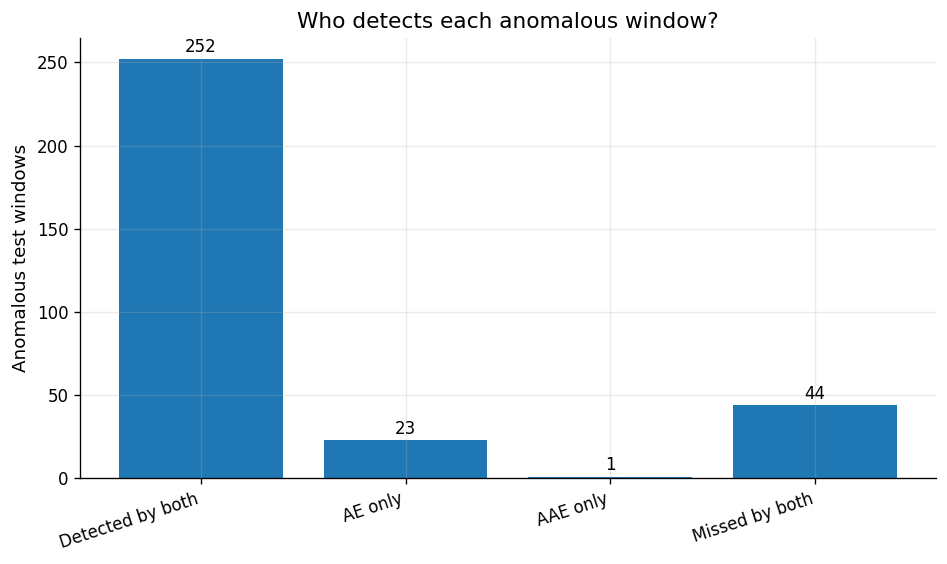

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/08_ae_aae_normal_window_agreement.png


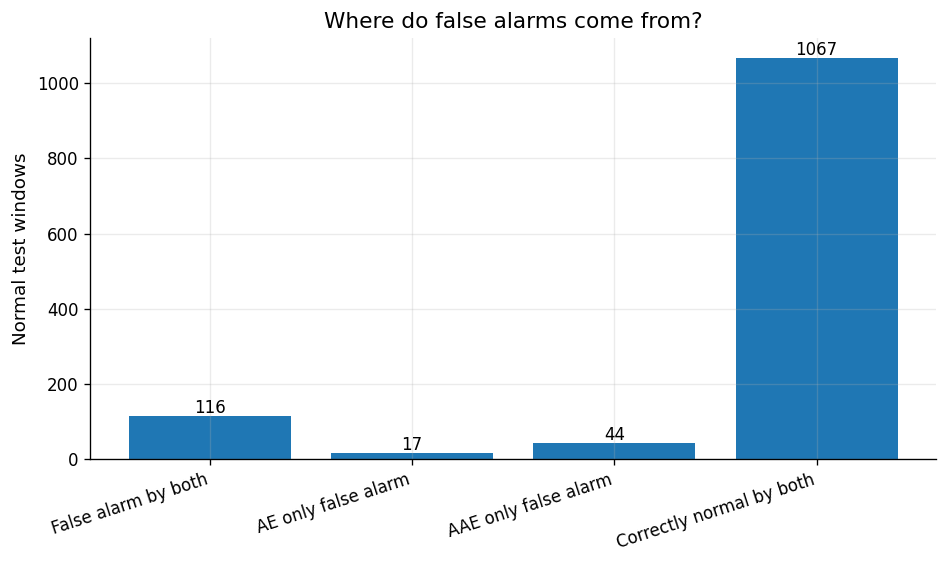

,anomalous_windows,normal_windows
AAE only,1.0,NaN
AAE only false alarm,NaN,44.0
AE only,23.0,NaN
AE only false alarm,NaN,17.0
Correctly normal by both,NaN,1067.0
Detected by both,252.0,NaN
False alarm by both,NaN,116.0
Missed by both,44.0,NaN


In [11]:
ae = runs['AE MLP — Smooth L1']['test'].copy()
aae = runs['AAE MLP — Smooth L1']['test'].copy()
merged = ae.merge(
    aae[['run_id', 'start', 'score', 'prediction']],
    on=['run_id', 'start'],
    suffixes=('_ae', '_aae'),
    validate='one_to_one',
)

anom = merged[merged['label'] == 1]
normal = merged[merged['label'] == 0]

anomaly_agreement = pd.Series({
    'Detected by both': int(((anom.prediction_ae == 1) & (anom.prediction_aae == 1)).sum()),
    'AE only': int(((anom.prediction_ae == 1) & (anom.prediction_aae == 0)).sum()),
    'AAE only': int(((anom.prediction_ae == 0) & (anom.prediction_aae == 1)).sum()),
    'Missed by both': int(((anom.prediction_ae == 0) & (anom.prediction_aae == 0)).sum()),
})

plt.figure(figsize=(8, 4.8))
plt.bar(anomaly_agreement.index, anomaly_agreement.values)
plt.ylabel('Anomalous test windows')
plt.title('Who detects each anomalous window?')
plt.xticks(rotation=18, ha='right')
for i, value in enumerate(anomaly_agreement.values):
    plt.text(i, value + 4, str(value), ha='center')
finish_figure('07_ae_aae_anomaly_window_agreement')

normal_agreement = pd.Series({
    'False alarm by both': int(((normal.prediction_ae == 1) & (normal.prediction_aae == 1)).sum()),
    'AE only false alarm': int(((normal.prediction_ae == 1) & (normal.prediction_aae == 0)).sum()),
    'AAE only false alarm': int(((normal.prediction_ae == 0) & (normal.prediction_aae == 1)).sum()),
    'Correctly normal by both': int(((normal.prediction_ae == 0) & (normal.prediction_aae == 0)).sum()),
})

plt.figure(figsize=(8, 4.8))
plt.bar(normal_agreement.index, normal_agreement.values)
plt.ylabel('Normal test windows')
plt.title('Where do false alarms come from?')
plt.xticks(rotation=18, ha='right')
for i, value in enumerate(normal_agreement.values):
    plt.text(i, value + 8, str(value), ha='center')
finish_figure('08_ae_aae_normal_window_agreement')

display(pd.DataFrame({'anomalous_windows': anomaly_agreement, 'normal_windows': normal_agreement}))

### Interpretation

A useful adversarial detector would ideally recover a meaningful set of anomalies missed by the plain AE. Instead, almost all AAE true positives are a subset of AE true positives, while the AAE adds more unique false positives than unique true positives. This is evidence that the adversarial constraint changes the representation without creating a new anomaly-discriminative direction.

## 9. Run-level event overlap

A run is considered detected when at least one of its anomalous windows is predicted positive. A normal run is considered disturbed when it contains at least one false-positive window.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/09_ae_aae_run_overlap.png


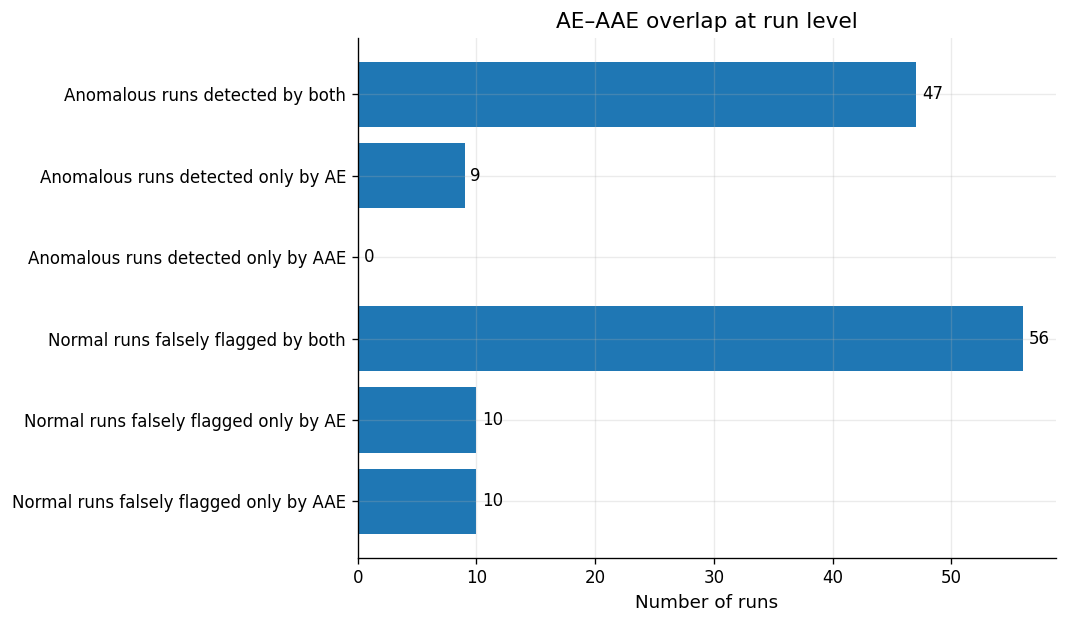

,category,count
0,Anomalous runs detected by both,47
1,Anomalous runs detected only by AE,9
2,Anomalous runs detected only by AAE,0
3,Normal runs falsely flagged by both,56
4,Normal runs falsely flagged only by AE,10
5,Normal runs falsely flagged only by AAE,10


In [12]:
def run_sets(df: pd.DataFrame):
    anomalous = df[df['label'] == 1].groupby('run_id')['prediction'].max()
    normal = df[df['label'] == 0].groupby('run_id')['prediction'].max()
    return set(anomalous[anomalous == 1].index), set(normal[normal == 1].index)

ae_detected, ae_fp_runs = run_sets(ae)
aae_detected, aae_fp_runs = run_sets(aae)

run_overlap = pd.DataFrame({
    'category': [
        'Anomalous runs detected by both',
        'Anomalous runs detected only by AE',
        'Anomalous runs detected only by AAE',
        'Normal runs falsely flagged by both',
        'Normal runs falsely flagged only by AE',
        'Normal runs falsely flagged only by AAE',
    ],
    'count': [
        len(ae_detected & aae_detected),
        len(ae_detected - aae_detected),
        len(aae_detected - ae_detected),
        len(ae_fp_runs & aae_fp_runs),
        len(ae_fp_runs - aae_fp_runs),
        len(aae_fp_runs - ae_fp_runs),
    ],
})

plt.figure(figsize=(9, 5.3))
plt.barh(run_overlap['category'][::-1], run_overlap['count'][::-1])
plt.xlabel('Number of runs')
plt.title('AE–AAE overlap at run level')
for i, value in enumerate(run_overlap['count'][::-1]):
    plt.text(value + 0.5, i, str(value), va='center')
finish_figure('09_ae_aae_run_overlap')
display(run_overlap)

## 10. Three representative runs

Scores from different detectors have different units. To make them comparable, each score is converted into a **standardized threshold margin**:

```text
(score − validation threshold) / std(normal validation scores)
```

Values above zero are predicted anomalous.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/10_case_slow_seg_0032.png


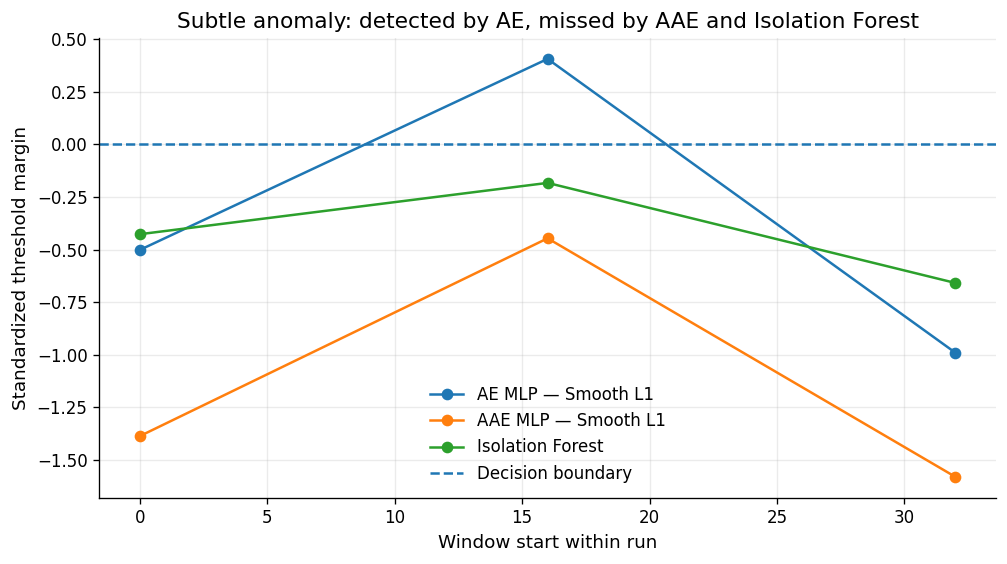

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/11_case_slow_seg_0131.png


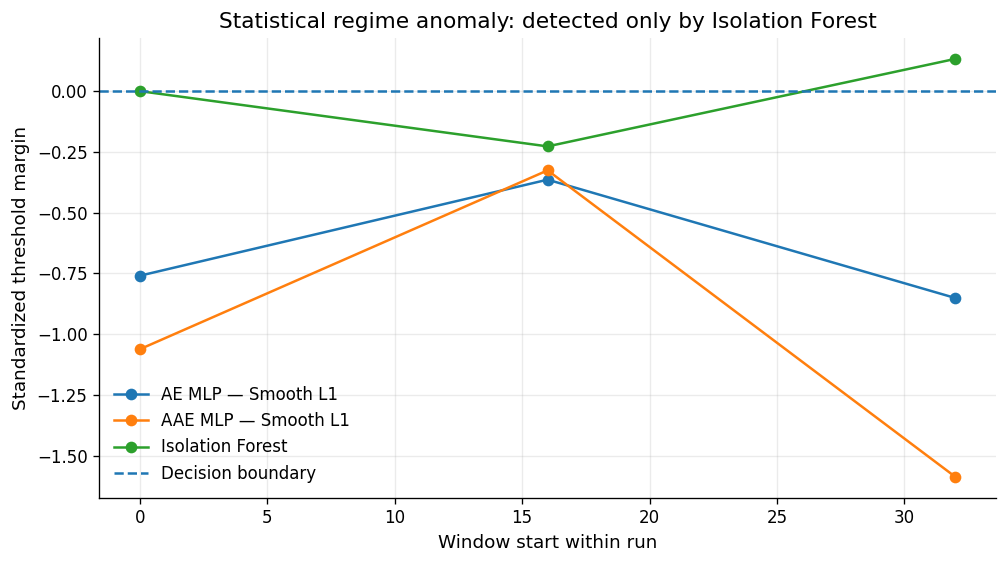

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/12_case_normal_seg_1362.png


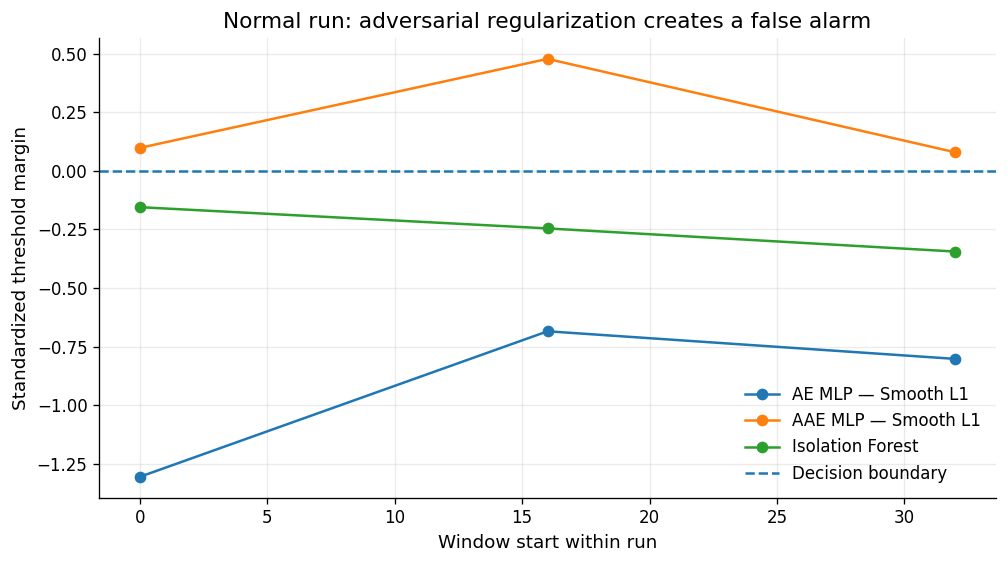

In [13]:
def plot_run_profile(run_id: str, model_names: list[str], title: str, figure_name: str):
    plt.figure(figsize=(8.5, 4.8))
    found = False
    for model_name in model_names:
        obj = runs[model_name]
        part = obj['test'][obj['test']['run_id'] == run_id].sort_values('start')
        if part.empty:
            continue
        found = True
        margin = (part['score'] - obj['threshold']) / obj['val_normal_std']
        plt.plot(part['start'], margin, marker='o', label=model_name)
    if not found:
        print(f'Run not found: {run_id}')
        plt.close()
        return
    plt.axhline(0, linestyle='--', linewidth=1.5, label='Decision boundary')
    plt.xlabel('Window start within run')
    plt.ylabel('Standardized threshold margin')
    plt.title(title)
    plt.legend()
    finish_figure(figure_name)

models_for_cases = ['AE MLP — Smooth L1', 'AAE MLP — Smooth L1', 'Isolation Forest']
plot_run_profile(
    'slow_seg_0032', models_for_cases,
    'Subtle anomaly: detected by AE, missed by AAE and Isolation Forest',
    '10_case_slow_seg_0032'
)
plot_run_profile(
    'slow_seg_0131', models_for_cases,
    'Statistical regime anomaly: detected only by Isolation Forest',
    '11_case_slow_seg_0131'
)
plot_run_profile(
    'normal_seg_1362', models_for_cases,
    'Normal run: adversarial regularization creates a false alarm',
    '12_case_normal_seg_1362'
)

# Part IV — Action-dependent difficulty

## 11. Recall by action

Only actions containing anomalous test windows are included. This avoids interpreting F1 or recall for actions where the positive class is absent.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/13_recall_by_action.png


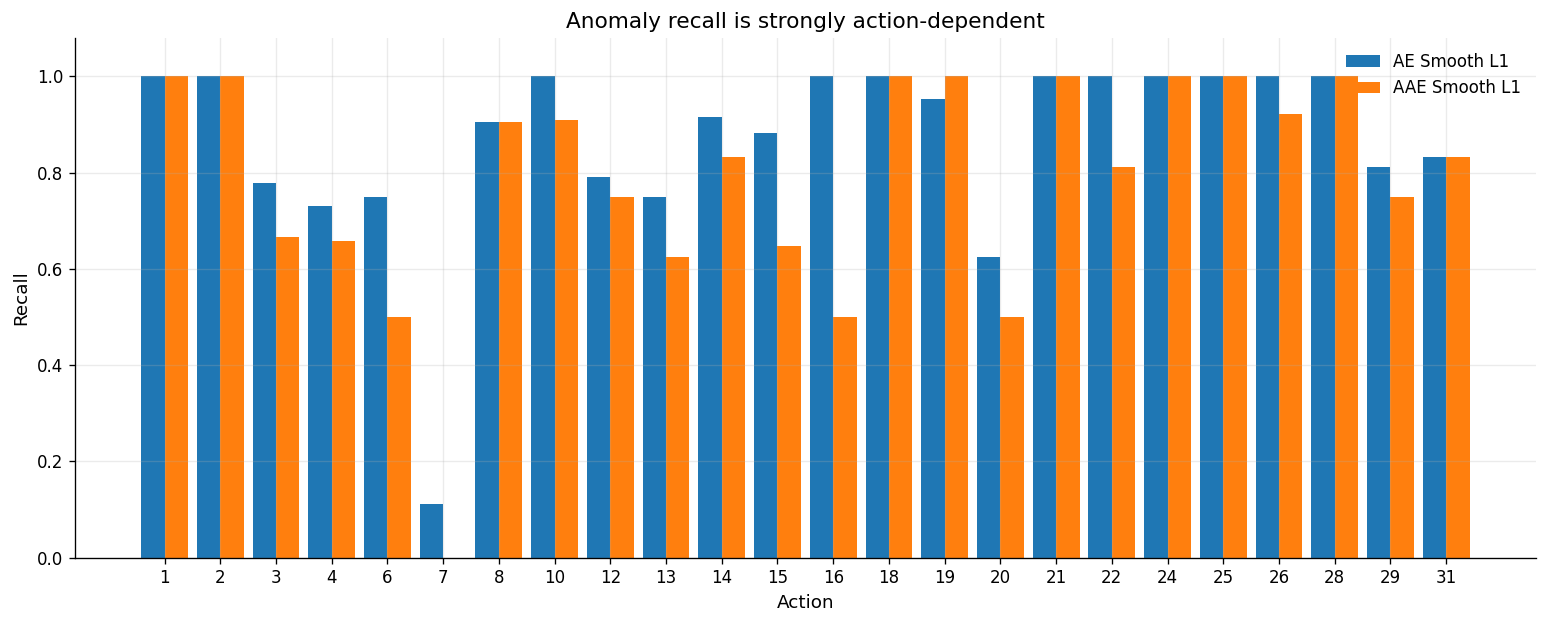

In [14]:
pa = per_action.copy()
pa['action'] = pa['action'].astype(int)
pa['model'] = pa['model'].replace({'AAE best score': 'AAE'})
with_anomalies = pa[pa['anomaly_prevalence'] > 0].copy()
recall_pivot = with_anomalies.pivot(index='action', columns='model', values='recall').sort_index()

x = np.arange(len(recall_pivot.index))
width = 0.42
plt.figure(figsize=(13, 5.3))
plt.bar(x - width/2, recall_pivot['AE'], width, label='AE Smooth L1')
plt.bar(x + width/2, recall_pivot['AAE'], width, label='AAE Smooth L1')
plt.xticks(x, recall_pivot.index)
plt.xlabel('Action')
plt.ylabel('Recall')
plt.ylim(0, 1.08)
plt.title('Anomaly recall is strongly action-dependent')
plt.legend()
finish_figure('13_recall_by_action')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/14_false_positive_rate_normal_actions.png


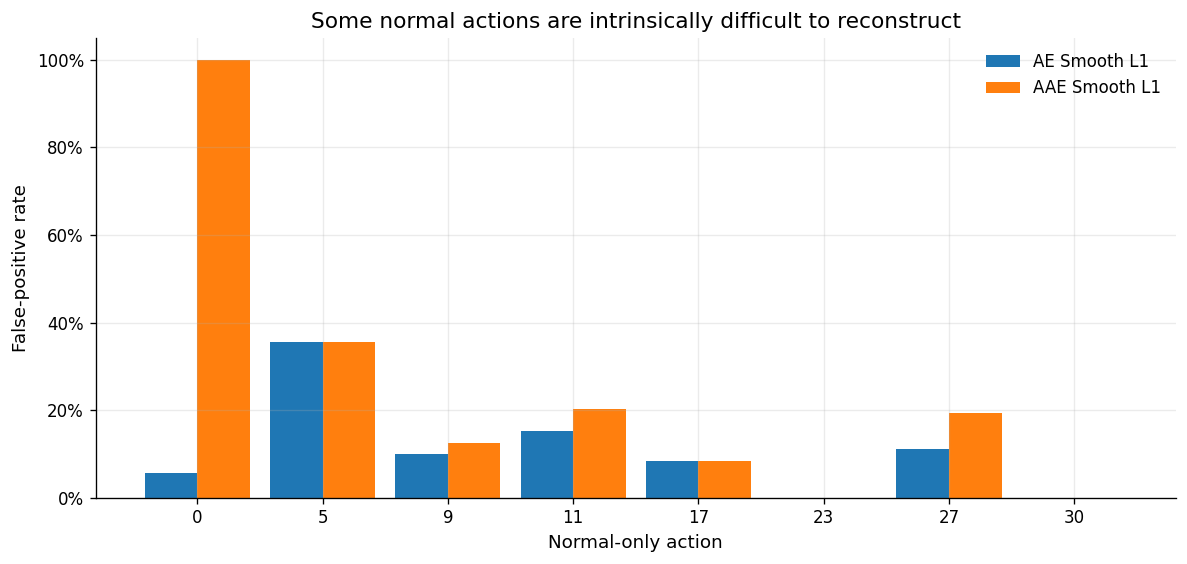

In [15]:
normal_only = pa[pa['anomaly_prevalence'] == 0].copy()
normal_only['false_positive_rate'] = normal_only['fp'] / (normal_only['fp'] + normal_only['tn']).clip(lower=1)
fpr_pivot = normal_only.pivot(index='action', columns='model', values='false_positive_rate').sort_index()

x = np.arange(len(fpr_pivot.index))
width = 0.42
plt.figure(figsize=(10, 4.8))
plt.bar(x - width/2, fpr_pivot['AE'], width, label='AE Smooth L1')
plt.bar(x + width/2, fpr_pivot['AAE'], width, label='AAE Smooth L1')
plt.xticks(x, fpr_pivot.index)
plt.xlabel('Normal-only action')
plt.ylabel('False-positive rate')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title('Some normal actions are intrinsically difficult to reconstruct')
plt.legend()
finish_figure('14_false_positive_rate_normal_actions')

### Interpretation

A single global threshold assumes that the same score has the same meaning for every action. The plots show that this assumption is weak: some actions are almost perfectly separated, while action 7 is nearly indistinguishable under reconstruction error. This motivates action-conditioned score normalization, thresholds, or latent priors.

# Part V — Physical interpretation of the feature signal

## 12. Feature-family decomposition

The 85 channels are grouped into orientation components (`q`), electrical quantities, gyroscopes, accelerometers and temperature.

In [16]:
def feature_family(feature: str) -> str:
    if feature.startswith('machine_nameKuka Robot_'):
        return 'Electrical'
    if '_Acc' in feature:
        return 'Accelerometer'
    if '_Gyro' in feature:
        return 'Gyroscope'
    if '_temp' in feature:
        return 'Temperature'
    if any(f'_q{i}' in feature for i in range(1, 5)):
        return 'Orientation q'
    return 'Other'

pf = per_feature.copy()
pf['family'] = pf['feature'].map(feature_family)

family_summary = pf.groupby('family', as_index=False).agg(
    n_features=('feature', 'size'),
    ae_normal_error=('ae_normal_error', 'mean'),
    ae_anomaly_error=('ae_anomaly_error', 'mean'),
    separation_ae=('separation_ae', 'mean'),
    aae_normal_error=('aae_normal_error', 'mean'),
    aae_anomaly_error=('aae_anomaly_error', 'mean'),
    separation_aae=('separation_aae', 'mean'),
)
family_summary['delta_aae_minus_ae'] = family_summary['separation_aae'] - family_summary['separation_ae']
family_summary = family_summary.sort_values('separation_ae', ascending=False)
display(family_summary.round(4))
family_summary.to_csv(TABLE_OUTPUT_DIR / 'feature_family_summary.csv', index=False)

,family,n_features,ae_normal_error,ae_anomaly_error,separation_ae,aae_normal_error,aae_anomaly_error,separation_aae,delta_aae_minus_ae
3,Orientation q,28,0.0437,0.2477,0.2040,0.0631,0.2792,0.2161,0.0121
1,Electrical,8,0.1818,0.2923,0.1104,0.2136,0.3136,0.1001,-0.0104
2,Gyroscope,21,0.0833,0.1357,0.0524,0.1129,0.1552,0.0423,-0.0101
4,Temperature,7,0.0079,0.0007,-0.0072,0.0079,0.0007,-0.0072,-0.0000
0,Accelerometer,21,0.1771,0.1687,-0.0084,0.1941,0.1680,-0.0262,-0.0178


Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/15_feature_family_separation.png


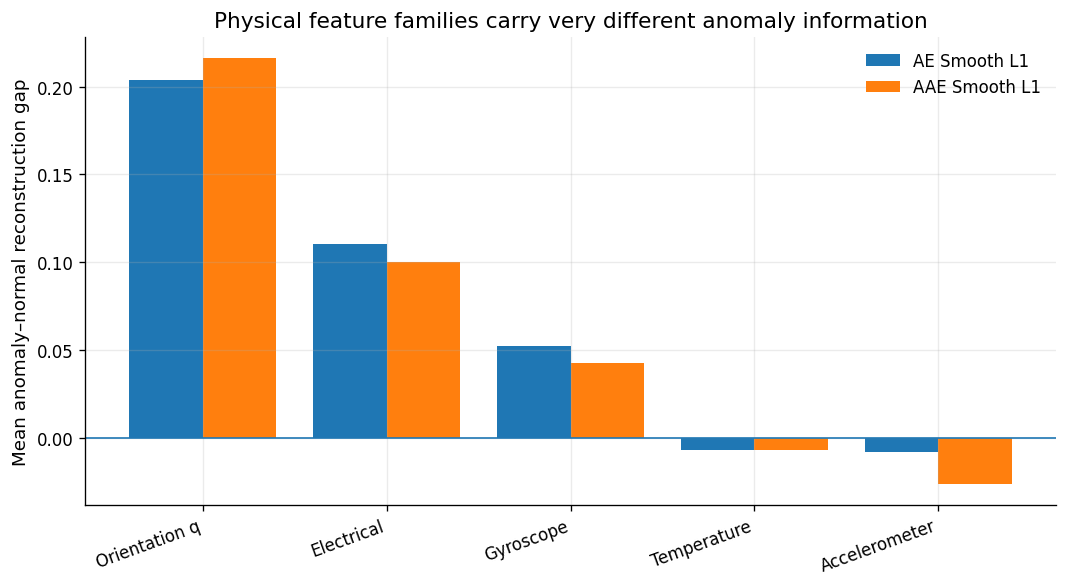

In [17]:
x = np.arange(len(family_summary))
width = 0.40
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, family_summary['separation_ae'], width, label='AE Smooth L1')
plt.bar(x + width/2, family_summary['separation_aae'], width, label='AAE Smooth L1')
plt.axhline(0, linewidth=1)
plt.xticks(x, family_summary['family'], rotation=20, ha='right')
plt.ylabel('Mean anomaly–normal reconstruction gap')
plt.title('Physical feature families carry very different anomaly information')
plt.legend()
finish_figure('15_feature_family_separation')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/16_feature_family_contribution.png


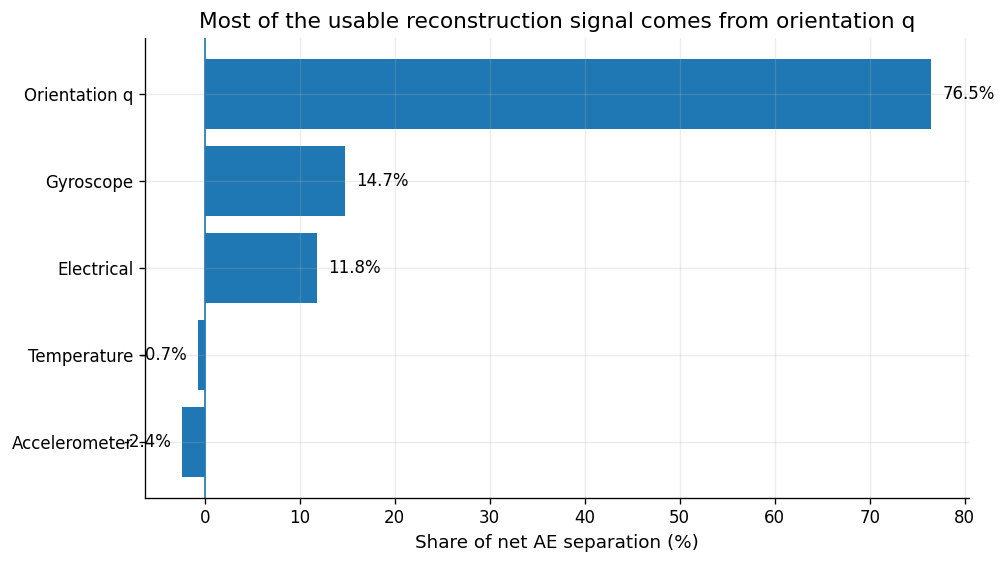

In [18]:
family_contrib = pf.groupby('family')['separation_ae'].sum().sort_values()
net = float(family_contrib.sum())
contrib_pct = 100 * family_contrib / net

plt.figure(figsize=(8.5, 4.8))
plt.barh(contrib_pct.index, contrib_pct.values)
plt.axvline(0, linewidth=1)
plt.xlabel('Share of net AE separation (%)')
plt.title('Most of the usable reconstruction signal comes from orientation q')
for i, value in enumerate(contrib_pct.values):
    plt.text(value + (1.2 if value >= 0 else -1.2), i, f'{value:.1f}%',
             va='center', ha='left' if value >= 0 else 'right')
finish_figure('16_feature_family_contribution')

## 13. Most informative and anti-informative channels

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/17_top_informative_features.png


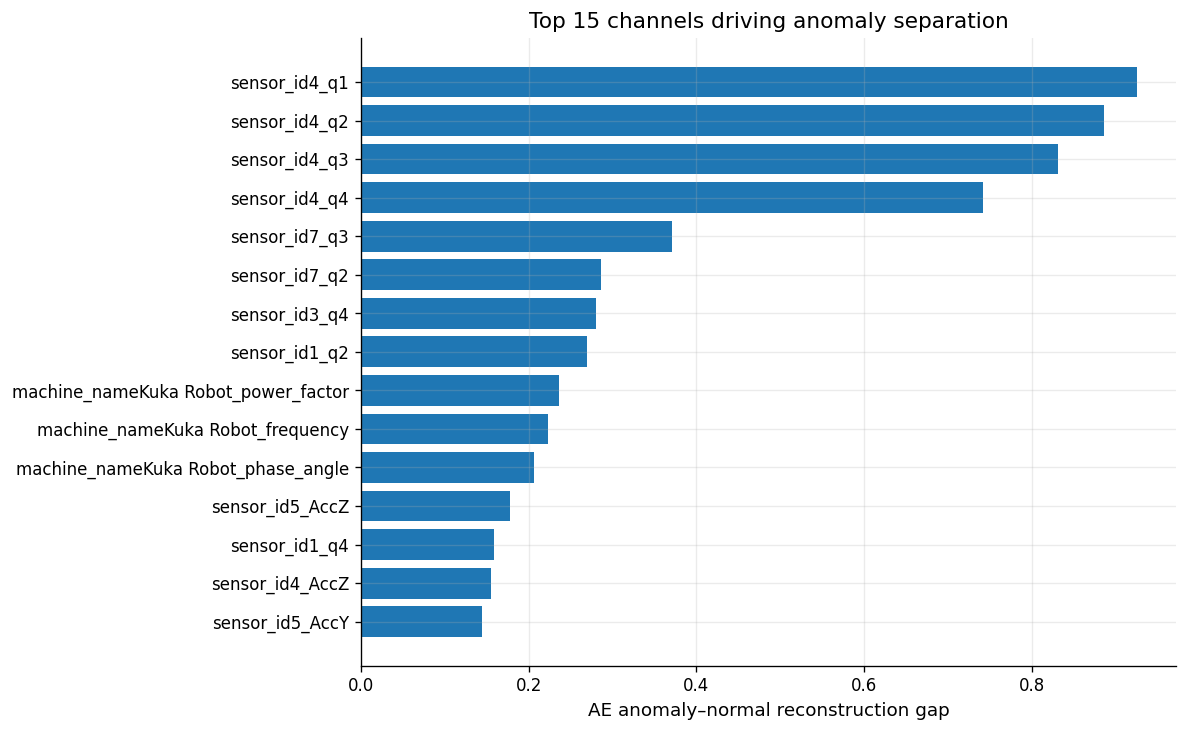

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/18_anti_informative_features.png


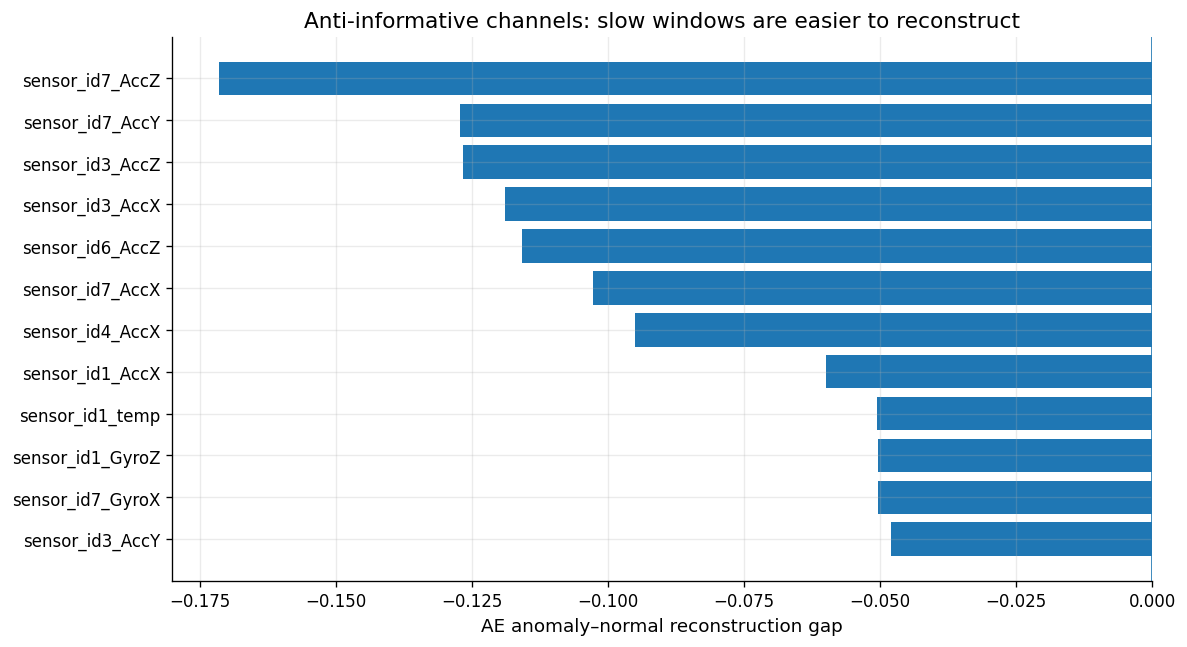

In [19]:
top = pf.nlargest(15, 'separation_ae').sort_values('separation_ae')
plt.figure(figsize=(10, 6.2))
plt.barh(top['feature'], top['separation_ae'])
plt.xlabel('AE anomaly–normal reconstruction gap')
plt.title('Top 15 channels driving anomaly separation')
finish_figure('17_top_informative_features')

bottom = pf.nsmallest(12, 'separation_ae').sort_values('separation_ae', ascending=False)
plt.figure(figsize=(10, 5.5))
plt.barh(bottom['feature'], bottom['separation_ae'])
plt.axvline(0, linewidth=1)
plt.xlabel('AE anomaly–normal reconstruction gap')
plt.title('Anti-informative channels: slow windows are easier to reconstruct')
finish_figure('18_anti_informative_features')

### Interpretation

- Orientation components dominate because slowdown changes the temporal progression of robot pose within a fixed 64-sample window.
- Electrical quantities provide a coherent regime signal, but frequency and voltage should be checked for session-related confounding.
- Many accelerometer channels are anti-informative: slower motion is smoother and therefore easier for a reconstruction model.
- Temperature channels contribute almost no useful information and include suspicious constant or implausible values.

## 14. How adversarial regularization changes the physical signal

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/19_aae_effect_by_feature_family.png


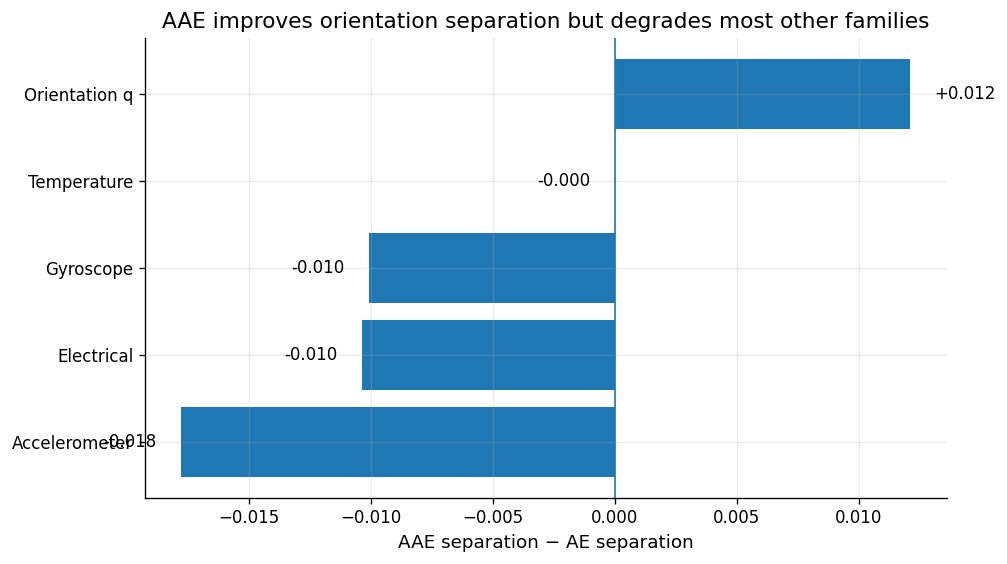

In [20]:
delta_family = family_summary.sort_values('delta_aae_minus_ae')
plt.figure(figsize=(8.5, 4.8))
plt.barh(delta_family['family'], delta_family['delta_aae_minus_ae'])
plt.axvline(0, linewidth=1)
plt.xlabel('AAE separation − AE separation')
plt.title('AAE improves orientation separation but degrades most other families')
for i, value in enumerate(delta_family['delta_aae_minus_ae']):
    plt.text(value + (0.001 if value >= 0 else -0.001), i, f'{value:+.3f}',
             va='center', ha='left' if value >= 0 else 'right')
finish_figure('19_aae_effect_by_feature_family')

# Part VI — Window length and selection bias

## 15. Window-length sensitivity

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/20_window_length_pr_auc.png


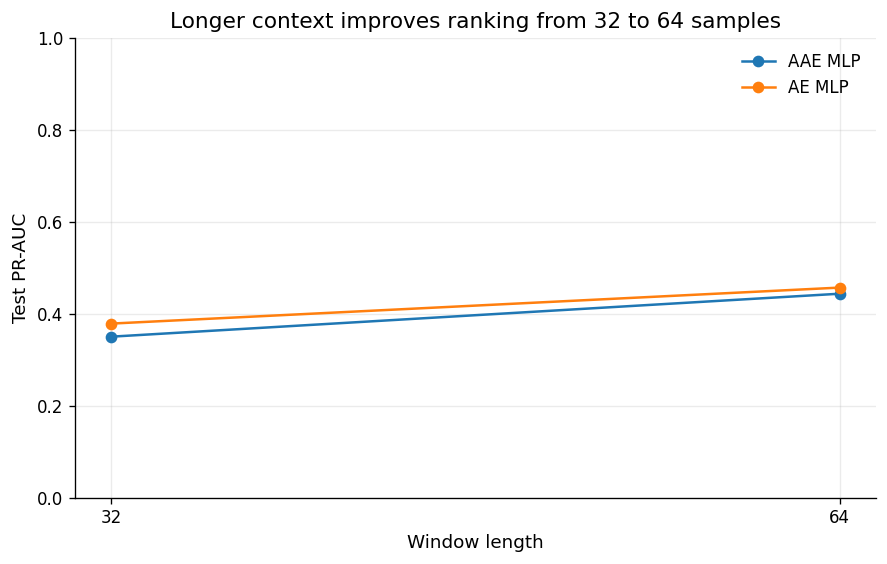

In [21]:
ws = window_sensitivity.copy().sort_values(['model', 'window_length'])
plt.figure(figsize=(7.5, 4.8))
for model, part in ws.groupby('model'):
    plt.plot(part['window_length'], part['test_pr_auc'], marker='o', label=model)
plt.xlabel('Window length')
plt.ylabel('Test PR-AUC')
plt.title('Longer context improves ranking from 32 to 64 samples')
plt.xticks(sorted(ws['window_length'].unique()))
plt.ylim(0, 1)
plt.legend()
finish_figure('20_window_length_pr_auc')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/21_segment_eligibility_by_window.png


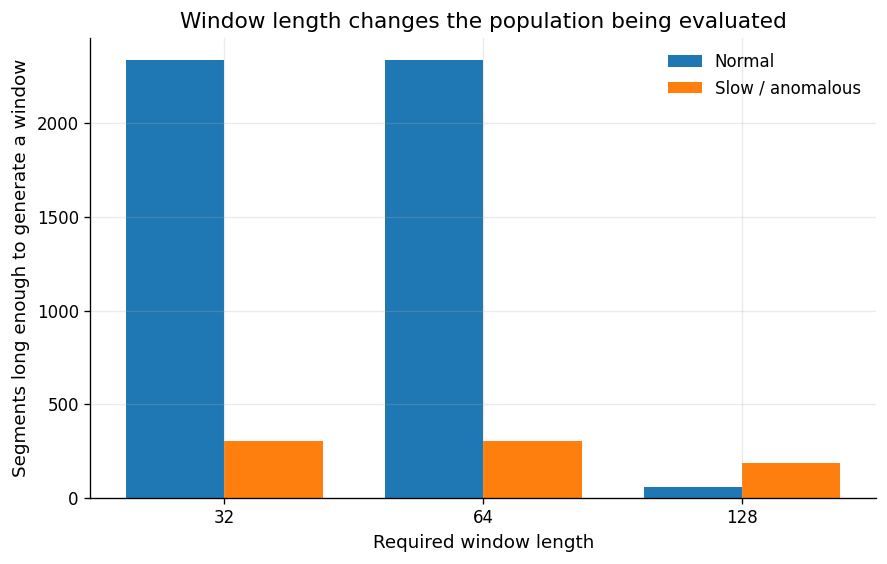

In [22]:
lengths = segment_lengths.copy()
lengths['class'] = np.where(lengths['label'].astype(int) == 1, 'Slow / anomalous', 'Normal')
rows = []
for window in [32, 64, 128]:
    eligible = lengths[lengths['length'] >= window]
    for cls, part in eligible.groupby('class'):
        rows.append({'window_length': window, 'class': cls, 'eligible_segments': len(part)})
eligibility = pd.DataFrame(rows)
pivot = eligibility.pivot(index='window_length', columns='class', values='eligible_segments').fillna(0)

x = np.arange(len(pivot.index))
width = 0.38
plt.figure(figsize=(7.5, 4.8))
plt.bar(x - width/2, pivot.get('Normal', pd.Series(0, index=pivot.index)), width, label='Normal')
plt.bar(x + width/2, pivot.get('Slow / anomalous', pd.Series(0, index=pivot.index)), width, label='Slow / anomalous')
plt.xticks(x, pivot.index)
plt.xlabel('Required window length')
plt.ylabel('Segments long enough to generate a window')
plt.title('Window length changes the population being evaluated')
plt.legend()
finish_figure('21_segment_eligibility_by_window')

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/22_eligible_segment_anomaly_share.png


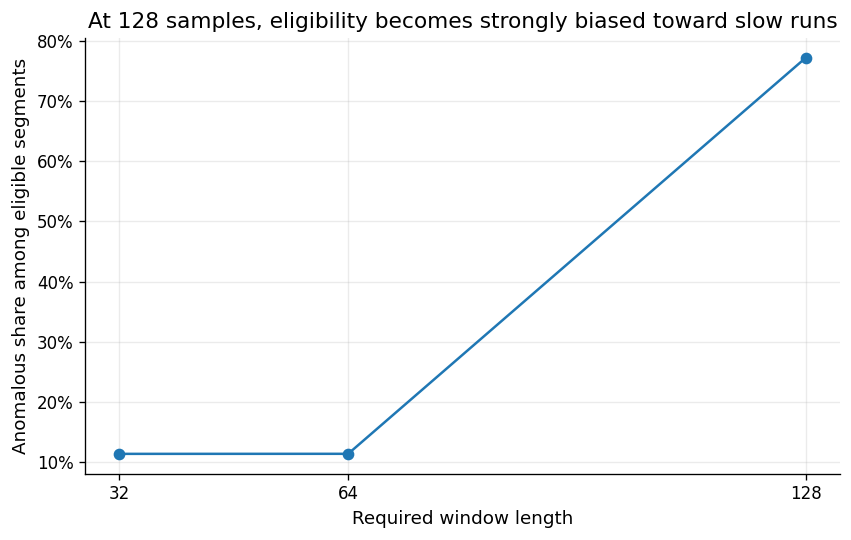

,window_length,eligible_segments,anomalous_segment_share
0,32,2641,0.113972
1,64,2639,0.114058
2,128,241,0.771784


In [23]:
prevalence_rows = []
for window in [32, 64, 128]:
    eligible = lengths[lengths['length'] >= window]
    prevalence_rows.append({
        'window_length': window,
        'eligible_segments': len(eligible),
        'anomalous_segment_share': eligible['label'].astype(int).mean(),
    })
prevalence_by_length = pd.DataFrame(prevalence_rows)

plt.figure(figsize=(7.2, 4.6))
plt.plot(prevalence_by_length['window_length'],
         prevalence_by_length['anomalous_segment_share'], marker='o')
plt.xlabel('Required window length')
plt.ylabel('Anomalous share among eligible segments')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title('At 128 samples, eligibility becomes strongly biased toward slow runs')
plt.xticks(prevalence_by_length['window_length'])
finish_figure('22_eligible_segment_anomaly_share')
display(prevalence_by_length)

### Interpretation

The improvement from 32 to 64 samples is consistent with a sustained-regime anomaly requiring temporal context. However, a 128-sample experiment would no longer evaluate the same population: most short normal segments disappear, while long slow segments remain. Any metric improvement at 128 would therefore be heavily confounded by selection bias.

# Part VII — The latent-space question

## 16. AAE latent PCA projection

This two-dimensional projection is descriptive only: it visualizes the first two principal directions of the learned latent codes, not the full 16-dimensional geometry.

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/23_aae_latent_pca.png


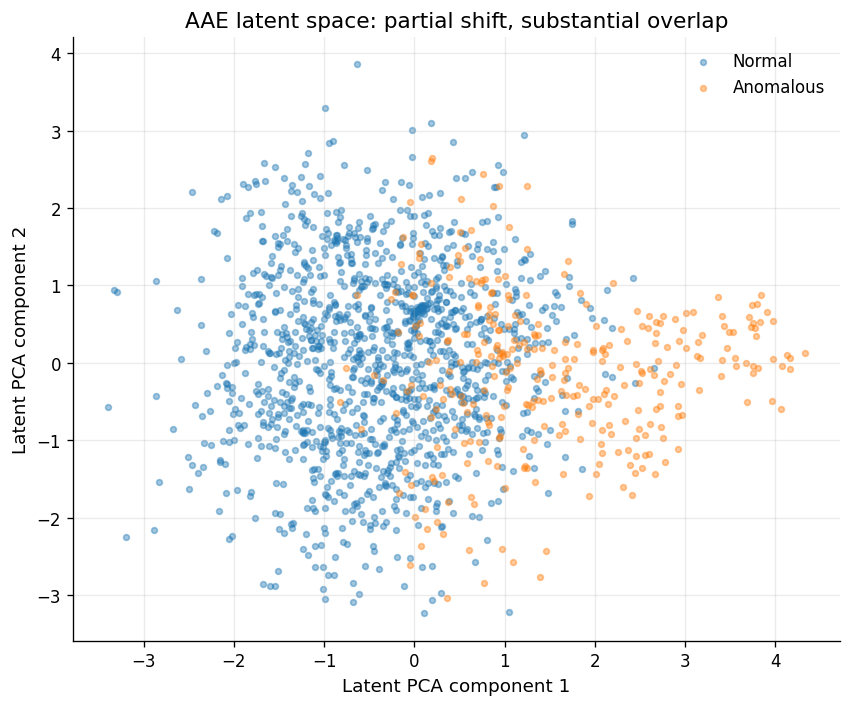

In [24]:
plt.figure(figsize=(7.2, 6.0))
for label_value, label_name in [(0, 'Normal'), (1, 'Anomalous')]:
    part = aae_latent[aae_latent['label'] == label_value]
    plt.scatter(part['pc1'], part['pc2'], s=12, alpha=0.42, label=label_name)
plt.xlabel('Latent PCA component 1')
plt.ylabel('Latent PCA component 2')
plt.title('AAE latent space: partial shift, substantial overlap')
plt.legend()
finish_figure('23_aae_latent_pca')

## 17. Are latent or discriminator scores useful for detection?

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/24_aae_specific_score_pr_auc.png


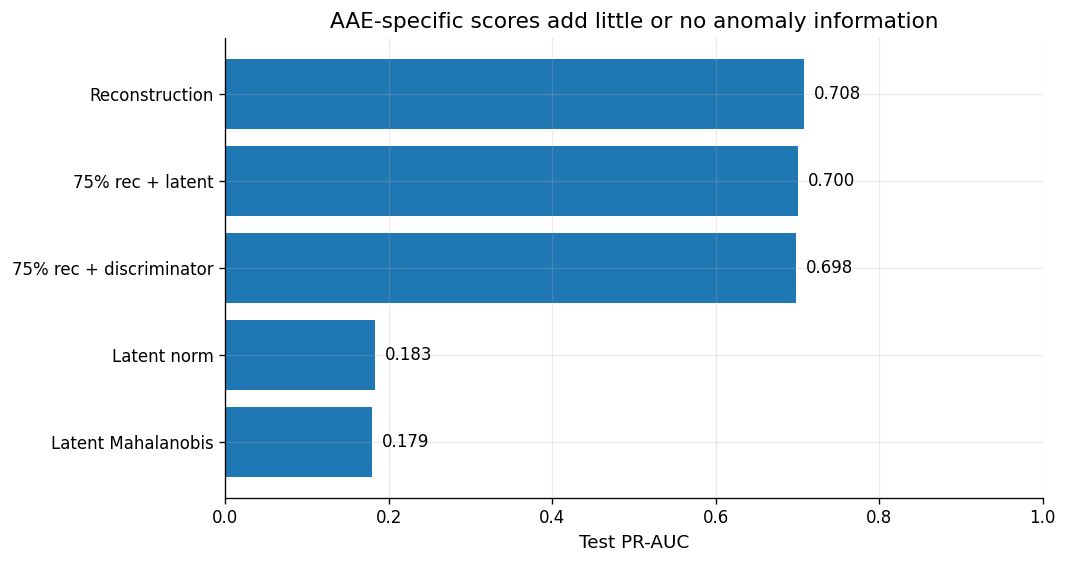

In [25]:
score_names = {
    'score_rec': 'Reconstruction',
    'score_combined_rec_disc_a0p75': '75% rec + discriminator',
    'score_combined_rec_latent_a0p75': '75% rec + latent',
    'score_latent_norm': 'Latent norm',
    'score_latent_mahalanobis': 'Latent Mahalanobis',
    'score_discriminator': 'Discriminator',
}
score_plot = aae_scores[aae_scores['aae_score'].isin(score_names)].copy()
score_plot['display'] = score_plot['aae_score'].map(score_names)
score_plot = score_plot.sort_values('test_pr_auc')

plt.figure(figsize=(9, 4.8))
plt.barh(score_plot['display'], score_plot['test_pr_auc'])
plt.xlabel('Test PR-AUC')
plt.title('AAE-specific scores add little or no anomaly information')
plt.xlim(0, 1)
for i, value in enumerate(score_plot['test_pr_auc']):
    plt.text(value + 0.012, i, f'{value:.3f}', va='center')
finish_figure('24_aae_specific_score_pr_auc')

### Interpretation

The discriminator was trained to distinguish **prior samples** from **encoder codes**, not normal robot behaviour from anomalies. Therefore, its output is not an anomaly probability. The strongest combined scores work only when reconstruction remains dominant; latent-only and discriminator-only scores are close to or below the anomaly prevalence baseline.

## 18. Warm-up diagnostics: optimization success versus task success

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/25_warmup_latent_regularization.png


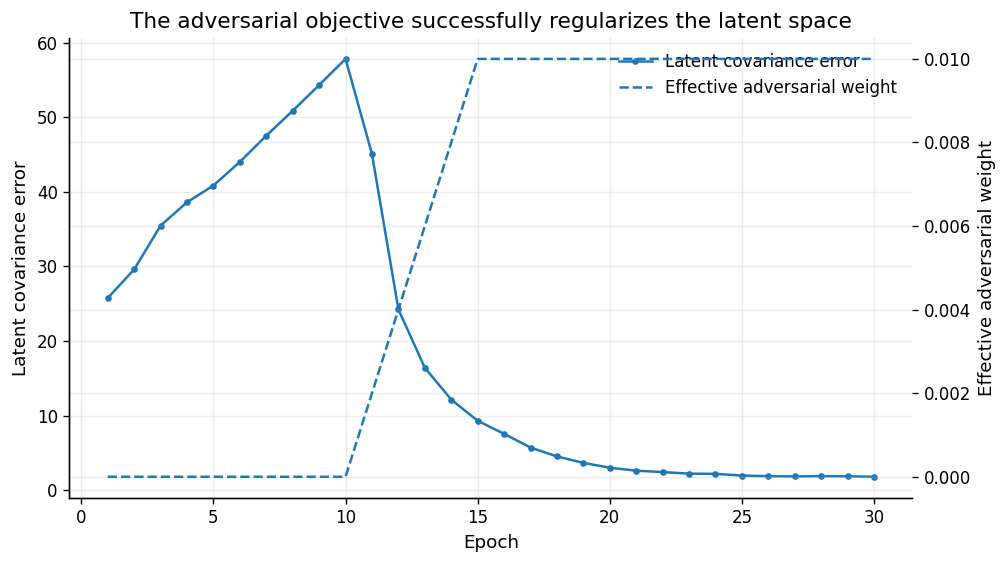

In [26]:
if warmup_history is None:
    print('Warm-up history not found; section skipped.')
else:
    hist = warmup_history.sort_values('epoch')
    fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
    ax1.plot(hist['epoch'], hist['latent_covariance_error'], marker='o', markersize=3,
             label='Latent covariance error')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Latent covariance error')
    ax2 = ax1.twinx()
    ax2.plot(hist['epoch'], hist['effective_lambda_adv'], linestyle='--',
             label='Effective adversarial weight')
    ax2.set_ylabel('Effective adversarial weight')
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')
    ax1.set_title('The adversarial objective successfully regularizes the latent space')
    plt.tight_layout()
    if SAVE_FIGURES:
        path = FIGURE_DIR / '25_warmup_latent_regularization.png'
        plt.savefig(path, bbox_inches='tight')
        print('Saved:', path)
    plt.show()

Saved: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook/26_warmup_grid_pr_auc.png


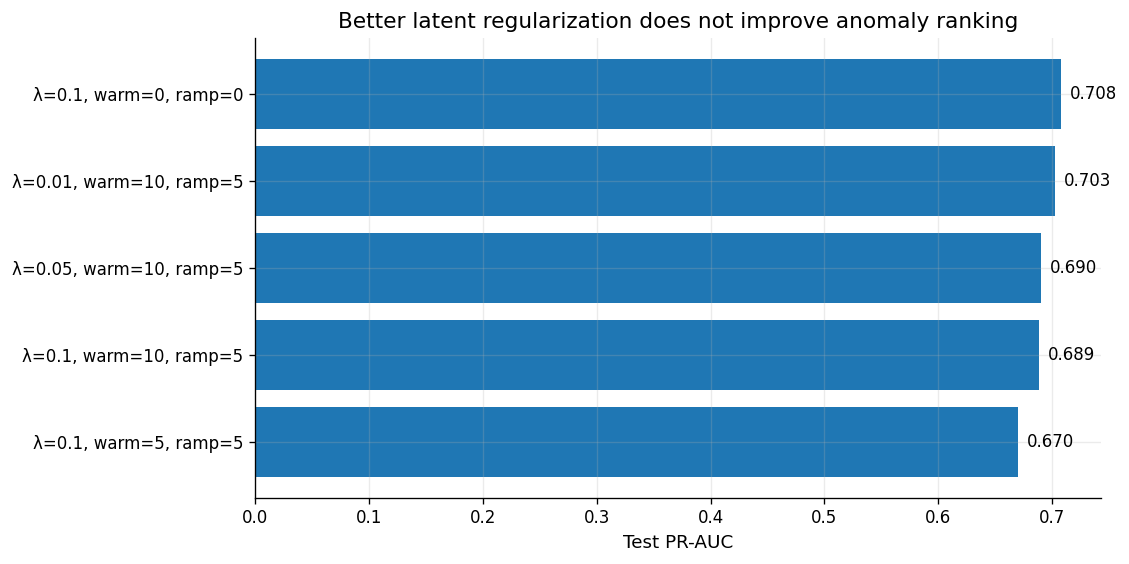

In [27]:
if warmup_grid is None:
    print('Warm-up grid not found; section skipped.')
else:
    wg = warmup_grid.copy()
    wg['setting'] = wg.apply(
        lambda r: f"λ={r['lambda_adv']:g}, warm={int(r['warmup_epochs'])}, ramp={int(r['ramp_epochs'])}",
        axis=1,
    )
    wg = wg.sort_values('test_pr_auc')
    plt.figure(figsize=(9.5, 4.8))
    plt.barh(wg['setting'], wg['test_pr_auc'])
    plt.xlabel('Test PR-AUC')
    plt.title('Better latent regularization does not improve anomaly ranking')
    for i, value in enumerate(wg['test_pr_auc']):
        plt.text(value + 0.008, i, f'{value:.3f}', va='center')
    finish_figure('26_warmup_grid_pr_auc')

# Final synthesis

The notebook provides visual evidence for the following conclusions:

1. **The anomaly type matters more than model complexity.** Isolation Forest is strong because slowdown changes window-level statistics directly.
2. **The original AE limitation was mainly the MSE score geometry.** Smooth L1 removes a large normal tail while preserving almost all true positives.
3. **The AAE does not add a complementary detector.** Its true positives are almost entirely a subset of AE detections, while it introduces extra false alarms and misses additional anomalous runs.
4. **The negative AAE result is not simply an optimization failure.** Warm-up and diagnostics show that the latent distribution is successfully regularized, but this does not align with anomaly separation.
5. **Normal behaviour is action-dependent and multimodal.** A single threshold and a single isotropic Gaussian prior are weak assumptions for 32 distinct robot actions.
6. **Most of the useful physical signal comes from orientation and electrical quantities.** Many accelerometer channels are anti-informative because slow motion is smoother and easier to reconstruct.
7. **Window length changes both context and sample selection.** The 64-sample setting is informative; 128 samples would strongly bias the eligible population toward slow runs.

The most defensible future experiments are therefore:

- action-conditioned thresholding or score normalization;
- quaternion-aware preprocessing and reconstruction loss;
- removal or validation of temperature, frequency and voltage channels;
- feature-family ablations and validation-calibrated weighted scores;
- multi-modal or action-conditioned latent priors instead of a single `N(0, I)` prior.

## 19. Export a compact interpretation summary

In [28]:
interpretation_summary = {
    'n_test_windows': int(len(ae)),
    'n_anomalous_test_windows': int(ae['label'].sum()),
    'ae_smoothl1': window_summary.set_index('model').loc['AE MLP — Smooth L1'].to_dict(),
    'aae_smoothl1': window_summary.set_index('model').loc['AAE MLP — Smooth L1'].to_dict(),
    'isolation_forest': window_summary.set_index('model').loc['Isolation Forest'].to_dict(),
    'anomaly_window_agreement': anomaly_agreement.to_dict(),
    'normal_window_agreement': normal_agreement.to_dict(),
    'feature_family_summary': family_summary.to_dict(orient='records'),
    'window_eligibility': prevalence_by_length.to_dict(orient='records'),
}

summary_path = TABLE_OUTPUT_DIR / 'interpretation_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(interpretation_summary, f, indent=2, default=float)
print('Saved:', summary_path)
print('Figures directory:', FIGURE_DIR)

Saved: /content/drive/MyDrive/AM01/results/official/tables/interpretation_notebook/interpretation_summary.json
Figures directory: /content/drive/MyDrive/AM01/results/official/figures/interpretation_notebook
